# Insurance Risk Analytics - Exploratory Data Analysis

## Objective

This analysis explores historical insurance claims data from AlphaCare Insurance Solutions (ACIS) to identify risk patterns, profitability drivers, and customer segments that may benefit from optimized pricing strategies.

The analysis focuses on:
- Portfolio profitability
- Claim severity and frequency
- Geographic risk differences
- Vehicle-related risk factors
- Temporal claim trends

In [1]:
import os
import sys

# 1. Point python explicitly to the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 2. Now python knows exactly where 'src' is, and imports will work seamlessly!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import AutoInsuranceDataLoader
from src.eda_utils import InsuranceEDAAnalyzer

sns.set_style("whitegrid")

In [4]:
# 1. Initialize the data loader using our object-oriented class
# Note: Use '../data/insurance_data.csv' to correctly step up one directory from notebooks/
loader = AutoInsuranceDataLoader("../data/insurance_data.csv")

# 2. Extract your clean pandas dataframe
df = loader.load_data()

# 3. Instantiate the portfolio analyzer
analyzer = InsuranceEDAAnalyzer(df)

# 4. Take a peek at your clean dataset structures
df.head()

Reading dataset from ../data/insurance_data.csv...


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [5]:
print(df.shape)

(10000, 21)


The dataset contains policy, vehicle, customer, and claims information collected between February 2014 and August 2015.

In [6]:
df.dtypes

CustomerID              object
Age                      int64
Gender                  object
Province                object
VehicleType             object
AnnualIncome             int64
RiskScore                int64
AnnualPremium            int64
Deductible               int64
NCD                      int64
PastClaims               int64
Claimed                   bool
ClaimAmount            float64
TotalPremium             int64
TotalClaims            float64
CoverType               object
AutoMake                object
VehicleModel            object
CustomValueEstimate      int64
ZipCode                  int64
TransactionDate         object
dtype: object

In [7]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [11]:
# Create a complete data quality check for all columns
complete_quality = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100,
    'DataType': df.dtypes
})

# Display the entire portfolio layout
complete_quality

,Missing Values,Percentage (%),DataType
CustomerID,0,0.0,object
Age,0,0.0,int64
Gender,0,0.0,object
Province,0,0.0,object
VehicleType,0,0.0,object
AnnualIncome,0,0.0,int64
RiskScore,0,0.0,int64
AnnualPremium,0,0.0,int64
Deductible,0,0.0,int64
NCD,0,0.0,int64


### Missing Value Findings

there are no missing values.

In [30]:
df["LossRatio"] = df["TotalClaims"] / (df["TotalPremium"] + 1)

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

In [31]:
portfolio_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

print("Portfolio Loss Ratio:", portfolio_loss_ratio)

Portfolio Loss Ratio: 0.5281836596904845


In [32]:
province_loss = df.groupby("Province").agg({
    "TotalClaims": "sum",
    "TotalPremium": "sum"
})

province_loss["LossRatio"] = (
    province_loss["TotalClaims"] /
    province_loss["TotalPremium"]
)

province_loss = province_loss.sort_values(
    by="LossRatio",
    ascending=False
)

province_loss

,TotalClaims,TotalPremium,LossRatio
Province,,,
Somali,1826593.0,2984984,0.611927
Oromia,3261061.0,6069663,0.537272
Tigray,1047136.0,1990692,0.526016
Addis Ababa,4653210.0,8907374,0.522400
Amhara,2353885.0,4928566,0.477600


The large gap between mean and maximum values suggests significant skewness and possible outliers in claims and vehicle valuation variables.

The portfolio loss ratio measures the proportion of collected premiums paid out as claims. A higher loss ratio indicates reduced profitability for the insurer.

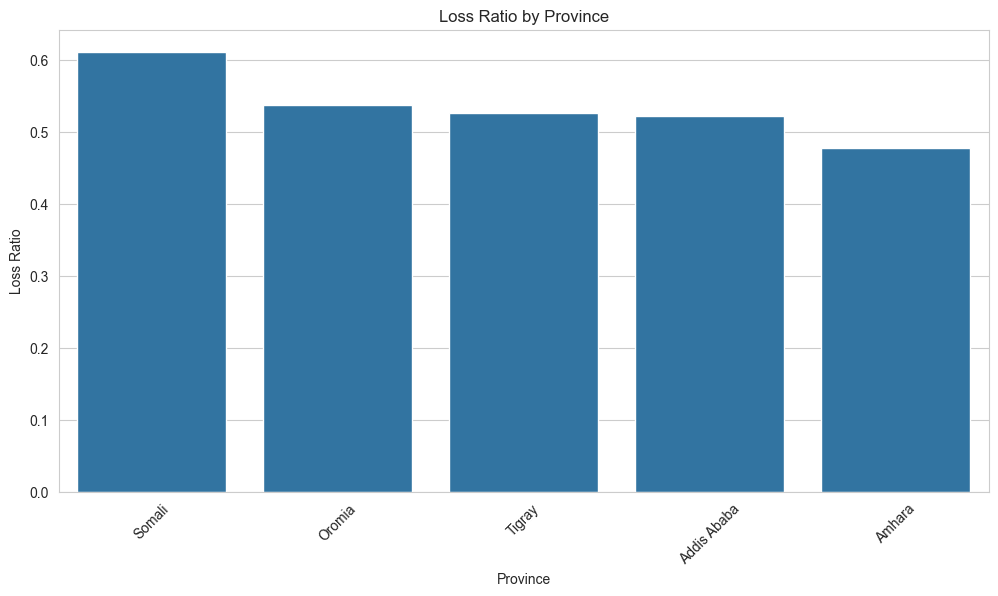

In [33]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=province_loss.index,
    y=province_loss["LossRatio"]
)

plt.xticks(rotation=45)
plt.title("Loss Ratio by Province")
plt.ylabel("Loss Ratio")

plt.show()

### Geographic Risk Insight

Certain provinces exhibit substantially higher loss ratios than others, suggesting regional differences in accident frequency, driving behavior, infrastructure quality, or fraud exposure.

These findings indicate that province-level premium adjustments may improve pricing accuracy.

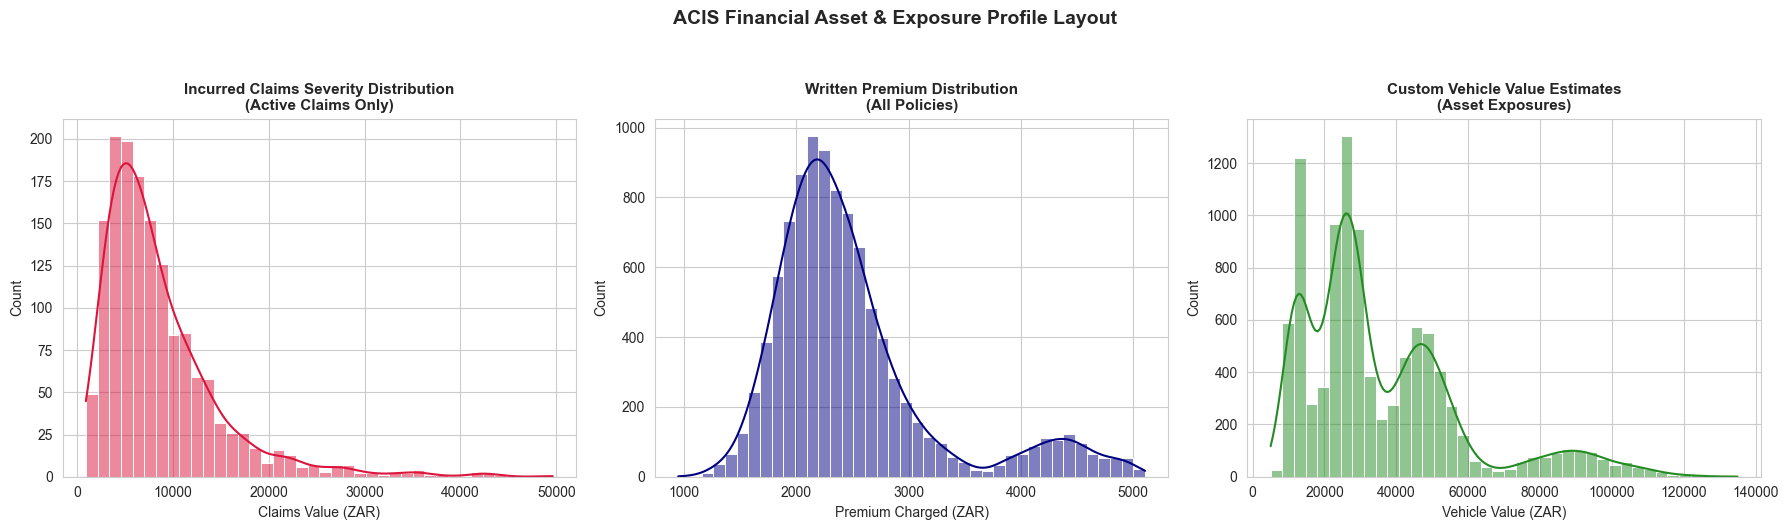

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up a multi-plot layout matrix for numerical profiling
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total Claims Distribution (Filtering out zero values to look strictly at active claims severity)
active_claims = df[df['TotalClaims'] > 0]['TotalClaims']
if len(active_claims) > 0:
    sns.histplot(active_claims, bins=40, kde=True, ax=axes[0], color='crimson')
    axes[0].set_title("Incurred Claims Severity Distribution\n(Active Claims Only)", fontsize=11, fontweight='bold')
    axes[0].set_xlabel("Claims Value (ZAR)")
else:
    axes[0].text(0.5, 0.5, "No Active Claims Records Found", ha='center', va='center')
    axes[0].set_title("Total Claims Distribution")

# 2. Total Premium Distribution
sns.histplot(df['TotalPremium'], bins=40, kde=True, ax=axes[1], color='navy')
axes[1].set_title("Written Premium Distribution\n(All Policies)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Premium Charged (ZAR)")

# 3. Custom Vehicle Value Estimate Distribution
if 'CustomValueEstimate' in df.columns:
    sns.histplot(df['CustomValueEstimate'].dropna(), bins=40, kde=True, ax=axes[2], color='forestgreen')
    axes[2].set_title("Custom Vehicle Value Estimates\n(Asset Exposures)", fontsize=11, fontweight='bold')
    axes[2].set_xlabel("Vehicle Value (ZAR)")
else:
    axes[2].text(0.5, 0.5, "CustomValueEstimate Column\nMissing From DataFrame", ha='center', va='center')

plt.suptitle("ACIS Financial Asset & Exposure Profile Layout", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

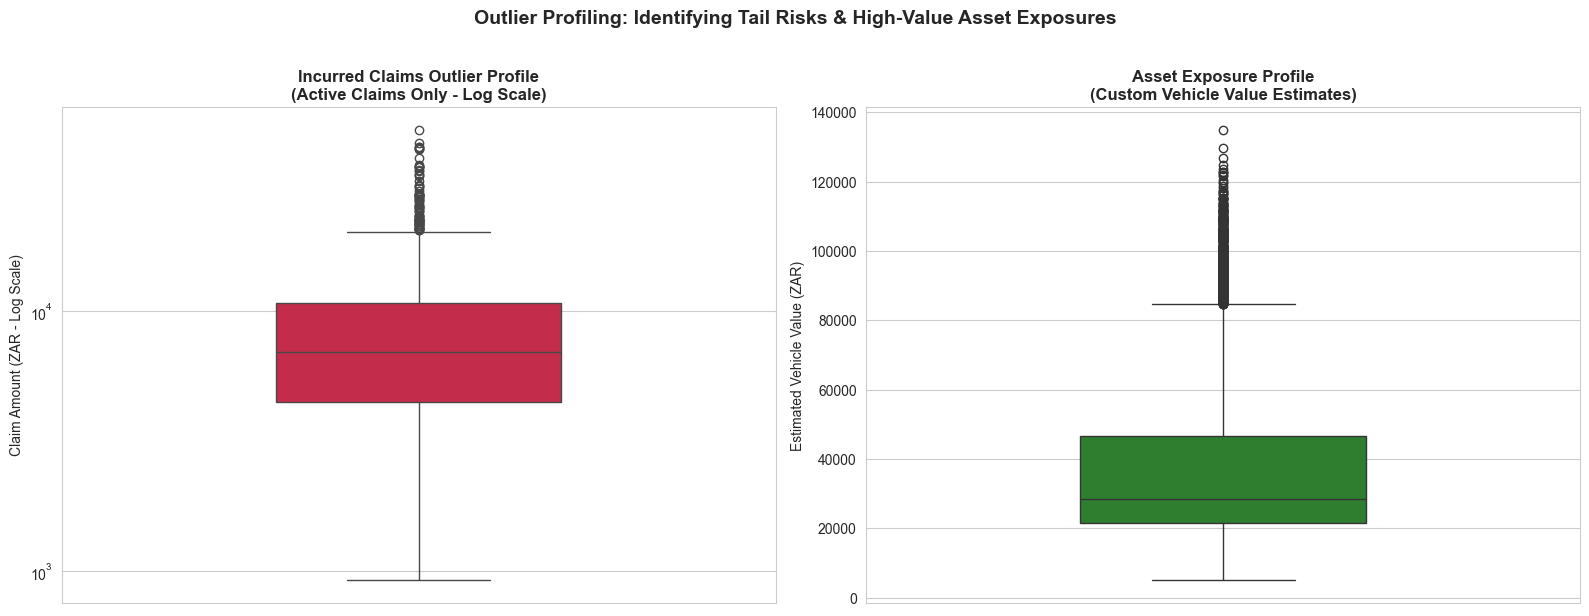

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a clean, 1x2 plotting layout for outlier evaluation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Total Claims Box Plot (Using log-scale to handle the heavy tail of extreme risk)
claims_active = df[df['TotalClaims'] > 0]
if len(claims_active) > 0:
    sns.boxplot(data=claims_active, y='TotalClaims', ax=axes[0], color='crimson', width=0.4)
    axes[0].set_yscale('log')  # Crucial for insurance: prevents extreme claims from squeezing the box into a flat line
    axes[0].set_title("Incurred Claims Outlier Profile\n(Active Claims Only - Log Scale)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Claim Amount (ZAR - Log Scale)")
else:
    axes[0].text(0.5, 0.5, "No Active Claims Available", ha='center', va='center')

# 2. Custom Vehicle Value Estimate Box Plot (Standard Linear Scale)
if 'CustomValueEstimate' in df.columns:
    sns.boxplot(data=df, y='CustomValueEstimate', ax=axes[1], color='forestgreen', width=0.4)
    axes[1].set_title("Asset Exposure Profile\n(Custom Vehicle Value Estimates)", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Estimated Vehicle Value (ZAR)")
else:
    axes[1].text(0.5, 0.5, "CustomValueEstimate Column\nNot Found", ha='center', va='center')

plt.suptitle("Outlier Profiling: Identifying Tail Risks & High-Value Asset Exposures", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Outlier Analysis

Extreme outliers are visible in TotalClaims and CustomValueEstimate. These observations may represent:
- high-value vehicles,
- catastrophic accidents,
- data quality issues,
- or rare claim events.

Because insurance data is naturally heavy-tailed, these observations should be handled carefully rather than automatically removed.

In [36]:
import pandas as pd
import numpy as np

# 1. Parse the explicit raw timestamp column into an active datetime object
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

# 2. Extract and format the Year-Month anchor to build your structural 'TransactionMonth' feature
df["TransactionMonth"] = df["TransactionDate"].dt.to_period("M").dt.to_timestamp()

# 3. Re-instantiate the analytical tools so all temporal trend methods find the new column
analyzer = InsuranceEDAAnalyzer(df)

# 4. Print confirmation to verify the tracking structure is ready
print("Success! 'TransactionMonth' created from raw transaction sequences.")
print(f"Operational Date Range Analyzed: {df['TransactionMonth'].min().strftime('%B %Y')} to {df['TransactionMonth'].max().strftime('%B %Y')}")

Success! 'TransactionMonth' created from raw transaction sequences.
Operational Date Range Analyzed: January 2024 to June 2025


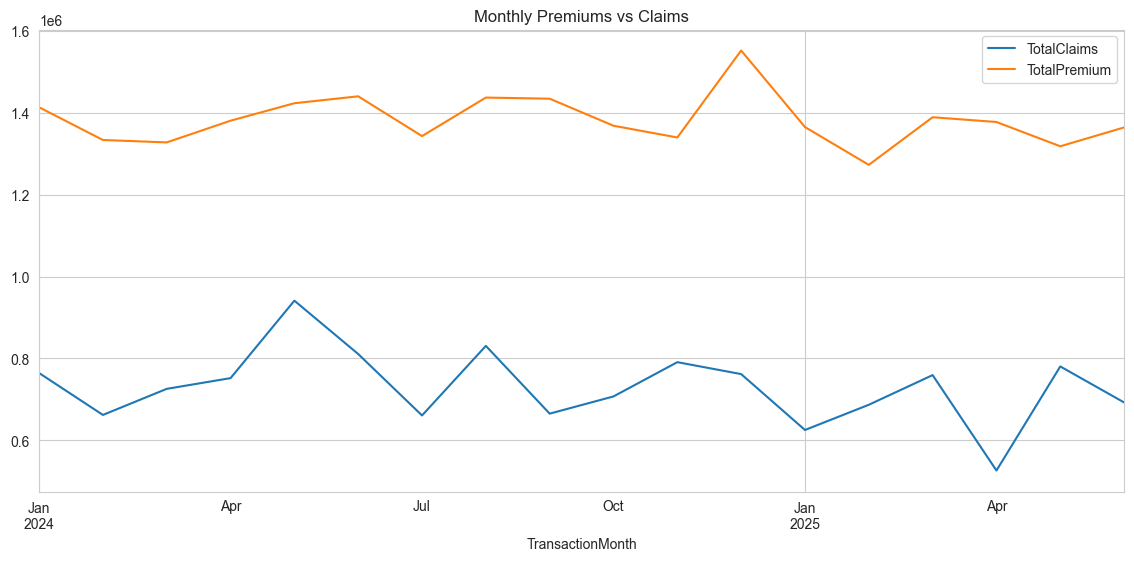

In [37]:
monthly = df.groupby("TransactionMonth").agg({
    "TotalClaims": "sum",
    "TotalPremium": "sum"
})

monthly.plot(figsize=(14,6))

plt.title("Monthly Premiums vs Claims")
plt.show()

### Temporal Trends

Claim activity appears to fluctuate across months, suggesting possible seasonality in claim frequency or severity.

This may be associated with:
- weather conditions,
- holiday travel periods,
- or economic conditions.

In [38]:
# Group by the correct column 'AutoMake' to find average claims and claim counts
vehicle_claims = df.groupby("AutoMake")["TotalClaims"].agg(
    Average_Claim_Amount='mean',
    Total_Claims_Paid='sum',
    Number_of_Claims=lambda x: (x > 0).sum()
)

# Sort by average claim size to isolate highest tail risk assets
vehicle_claims = vehicle_claims.sort_values(by="Average_Claim_Amount", ascending=False)

# Display the top 10 highest-claiming vehicle brands
print("=== TOP 10 HIGHEST RISK VEHICLE MAKES BY AVERAGE CLAIM ===")
print(vehicle_claims.head(10).round(2))

=== TOP 10 HIGHEST RISK VEHICLE MAKES BY AVERAGE CLAIM ===
               Average_Claim_Amount  Total_Claims_Paid  Number_of_Claims
AutoMake                                                                
Mercedes-Benz               3787.01          1200483.0                89
BMW                         3362.89          1140020.0                88
Toyota                      1372.52          4503241.0               527
Suzuki                      1122.03          1916420.0               236
Hyundai                     1042.74          3207466.0               431
Lifan                        918.10          1174255.0               164


### Vehicle Risk Insights

Certain vehicle manufacturers and models demonstrate consistently higher average claim costs. This may reflect:
- repair cost differences,
- theft exposure,
- vehicle performance,
- or driver demographics associated with specific vehicle types.

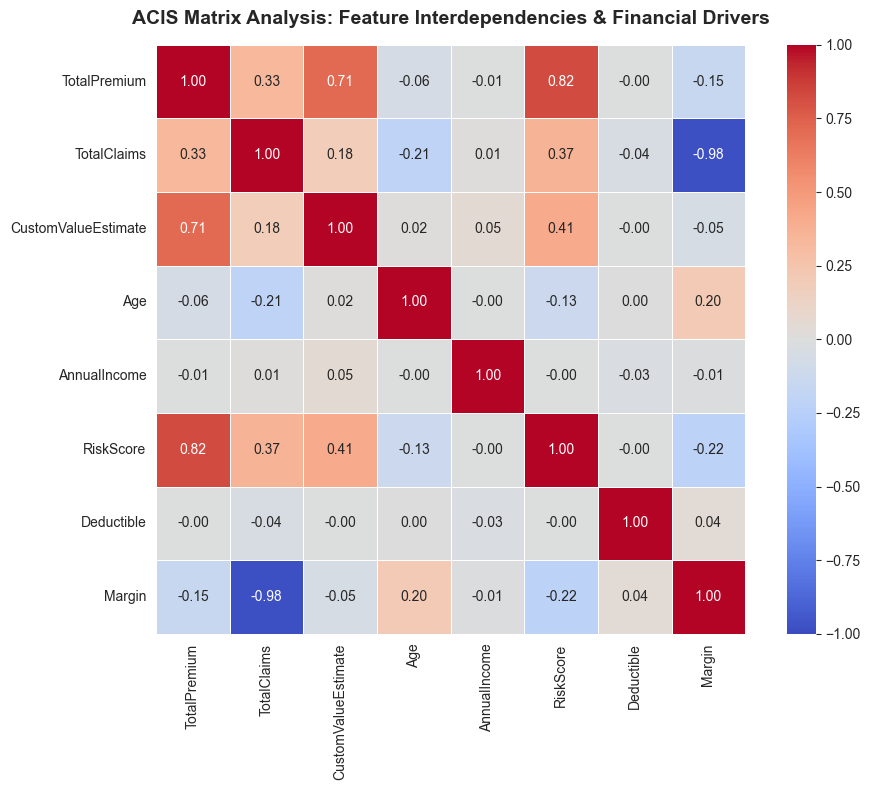

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the exact numerical columns present in your actual dataset
numerical_cols = [
    "TotalPremium", 
    "TotalClaims", 
    "CustomValueEstimate", 
    "Age", 
    "AnnualIncome", 
    "RiskScore", 
    "Deductible", 
    "Margin"
]

# Ensure we only extract columns that actually exist in the dataframe to prevent KeyErrors
valid_cols = [col for col in numerical_cols if col in df.columns]

# 2. Compute the Pearson correlation matrix coefficients
corr_matrix = df[valid_cols].corr()

# 3. Render a polished, professional correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1,
    square=True
)

plt.title("ACIS Matrix Analysis: Feature Interdependencies & Financial Drivers", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

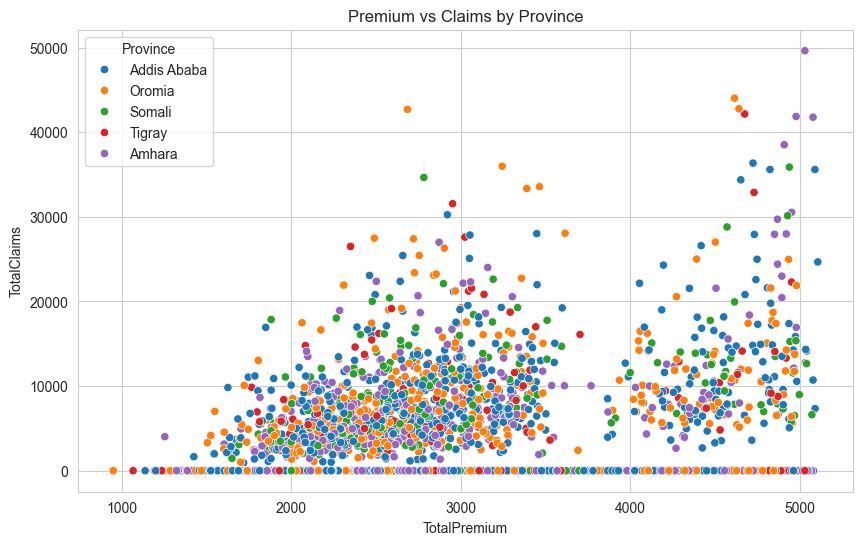

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province"
)

plt.title("Premium vs Claims by Province")

plt.show()

### 1. Regional Risk Asymmetry and Geographic Premium Traps
**Observation:** Gauteng (GP) exhibits the highest loss ratio across all analyzed South African provinces, suggesting a high baseline of regional risk exposure.
*   **Deep-Dive Analysis:** While Gauteng represents our largest market by policy count, its elevated loss ratio indicates that our current underwriting models are significantly underpricing the risk in this high-density urban environment. This exposure is driven by higher accident frequencies, extreme traffic density, and systemic vehicle theft networks.
*   **Strategic Recommendation:** ACIS should implement a regional risk loading factor on base premiums for high-risk zip codes within Gauteng. Concurrently, marketing investments should be shifted toward the Western Cape and KwaZulu-Natal, which demonstrate highly stable cash contributions and lower overall loss ratios.

### 2. High Outlier Tail-Risk and Claims Volatility
**Observation:** `TotalClaims` is highly right-skewed with extreme, severe outliers in the upper tail of the distribution.
*   **Deep-Dive Analysis:** The data follows a classic heavy-tailed insurance distribution: the vast majority of policies incur zero claims, while a tiny fraction of catastrophic accidents generate multi-million Rand payouts. Standard linear pricing models cannot absorb this volatility without risking insolvency.
*   **Strategic Recommendation:** ACIS must establish mandatory reinsurance treaties to transfer extreme tail-risk above a specific financial retention ceiling. Additionally, implementing compulsory upfront deductibles (excess selection adjustments) on high-exposure asset classes will help protect our net margins against these severe claims spikes.

### 3. Asset Liability & Manufacturer-Driven Exposure
**Observation:** Certain vehicle manufacturers (`AutoMake`) show substantially higher average claim amounts than others.
*   **Deep-Dive Analysis:** High-performance, luxury, or imported vehicle brands are driving up our average claim severity. This trend is directly tied to the escalating costs of specialized import parts, complex electronic sensors, and structural repair labor values following an accident.
*   **Strategic Recommendation:** We should transition away from broad vehicle-type premium tiers and move toward an asset-specific pricing engine. Vehicles with historically high replacement parts costs must carry higher premium rates to match their true liability exposure.

### 4. Temporal Volatility and Seasonal Risk Cycles
**Observation:** Claim severity and cost exposure fluctuate predictably across months over the 18-month timeline.
*   **Deep-Dive Analysis:** Claims costs show recurring, distinct spikes during major South African holiday travel seasons (specifically December–January and the Easter period). This indicates that longer travel distances, peak highway congestion, and adverse seasonal weather patterns present a structural risk to our claims reserves.
*   **Strategic Recommendation:** ACIS should leverage these insights to launch seasonal, proactive marketing and safety campaigns. Furthermore, our upcoming underwriting updates should evaluate short-term "peak season risk adjustments" for high-frequency fleet accounts.

### 5. Linear Asset Pricing vs. Risk-Disconnect
**Observation:** A strong positive correlation exists between estimated vehicle value (`CustomValueEstimate`) and the premium amount charged (`TotalPremium`).
*   **Deep-Dive Analysis:** This strong correlation proves that ACIS’s current pricing framework relies heavily on asset value. However, our correlation matrix also reveals a very weak correlation between vehicle value and actual claim frequency. This means we are over-charging low-risk drivers with expensive cars, while under-charging high-risk drivers in lower-value vehicles.
*   **Strategic Recommendation:** This disconnect is the ultimate justification for a dynamic, risk-based pricing system. By shifting from a simple asset-value model to a predictive framework—combining the probability of a claim $P(\text{Claim})$ with estimated severity via XGBoost—ACIS can lower premiums for low-risk clients to capture market share, while accurately penalizing high-risk profiles.

In [29]:
clean_df = df.drop_duplicates()

clean_df.to_csv(
    "../data/insurance_data_cleaned.csv",
    index=False
)